#CASE STUDY

##Import Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.model_selection import GridSearchCV

## Load train and test data

In [ ]:
train_df = pd.read_csv('/content/drive/MyDrive/ICT_DSA.python/Datasets/Training_data.csv')
test_df = pd.read_csv('/content/drive/MyDrive/ICT_DSA.python/Datasets/Testing_data.csv')

##Understand the data

In [ ]:
train_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.4,No
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790,No
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,NaN,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.6,No


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   gender            5465 non-null   object 
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   object 
 4   Dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   object 
 7   MultipleLines     5634 non-null   object 
 8   InternetService   5634 non-null   object 
 9   OnlineSecurity    5465 non-null   object 
 10  OnlineBackup      5634 non-null   object 
 11  DeviceProtection  5634 non-null   object 
 12  TechSupport       5634 non-null   object 
 13  StreamingTV       5634 non-null   object 
 14  StreamingMovies   5634 non-null   object 
 15  Contract          5634 non-null   object 
 16  PaperlessBilling  5634 non-null   object 


In [ ]:
train_df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,5634.000000,5634.000000,5240.000000
mean,0.159744,32.606851,65.102052
std,0.366401,24.614976,30.056443
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,36.800000
50%,0.000000,29.000000,70.650000
75%,0.000000,56.000000,90.050000
max,1.000000,72.000000,118.750000


In [ ]:
train_df.isna().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


In [ ]:
#Add Indicator column
train_df['dataset_type'] = 'train'
test_df['dataset_type'] = 'test'

In [ ]:
# Combine train and test data
customer_df = pd.concat([train_df, test_df], axis=0)

customer_df.reset_index(drop=True, inplace=True)

In [ ]:
# Data type conversion
customer_df['TotalCharges'] = pd.to_numeric(
    customer_df['TotalCharges'],
    errors='coerce'
)

In [ ]:
#missing values
customer_df.isna().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


In [ ]:
# seperate numerical and categorical columns
num_cols = customer_df.select_dtypes(include=['number']).columns

cat_cols = customer_df.select_dtypes(include=['object']).columns

##EDA

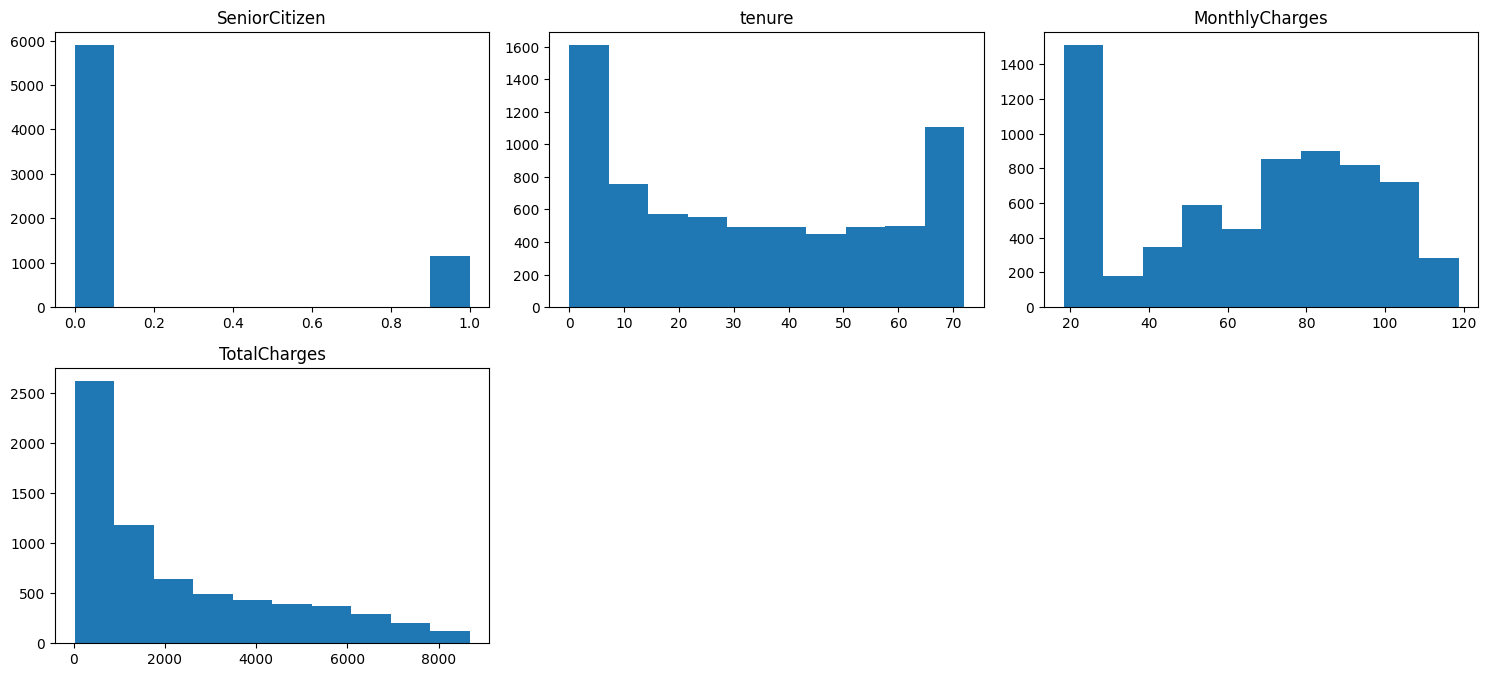

In [ ]:
#distribution of numerical columns
plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(3,3,i)
    plt.hist(customer_df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

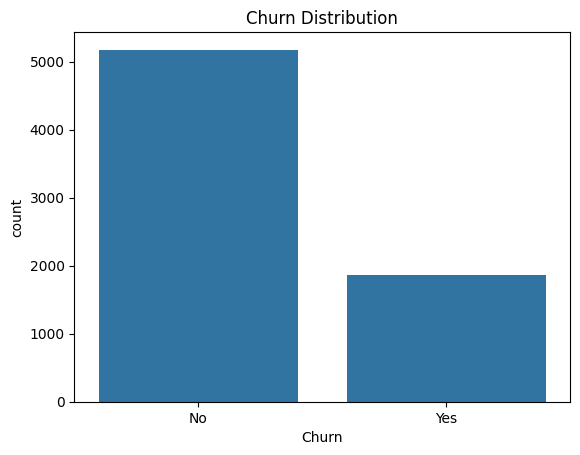

In [ ]:
# Countplot for churn
sns.countplot(x='Churn', data=customer_df)
plt.title('Churn Distribution')
plt.show

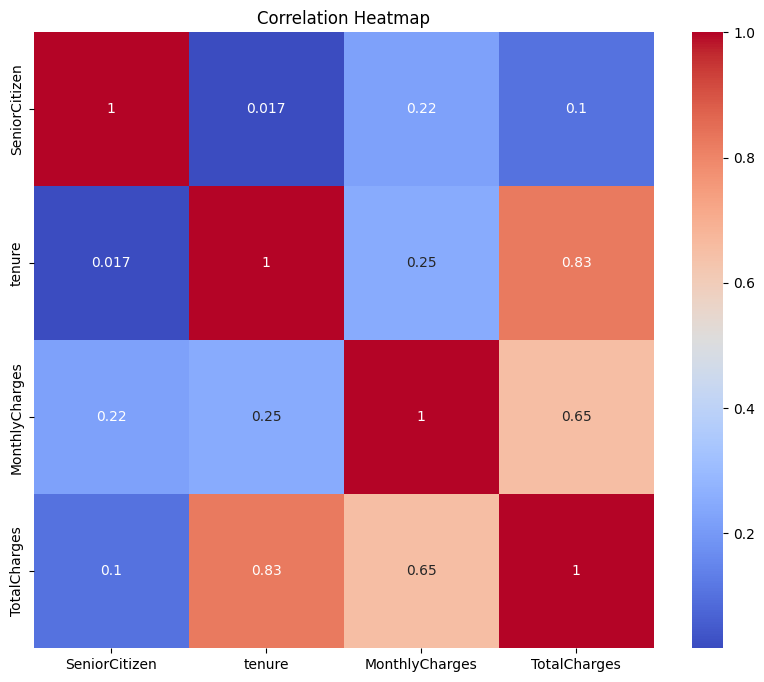

In [ ]:
#heatmap
corr_matrix = customer_df[num_cols].corr()

plt.figure(figsize=(10,8))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

In [ ]:
#Handle missing values : numerical columns - median
for col in num_cols:
    customer_df[col].fillna(customer_df[col].median(), inplace=True)

/tmp/ipykernel_13160/3405056605.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  customer_df[col].fillna(customer_df[col].median(), inplace=True)


In [ ]:
# categorical : mode
for col in cat_cols:
    customer_df[col].fillna(customer_df[col].mode()[0], inplace=True)

/tmp/ipykernel_13160/3623066585.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  customer_df[col].fillna(customer_df[col].mode()[0], inplace=True)


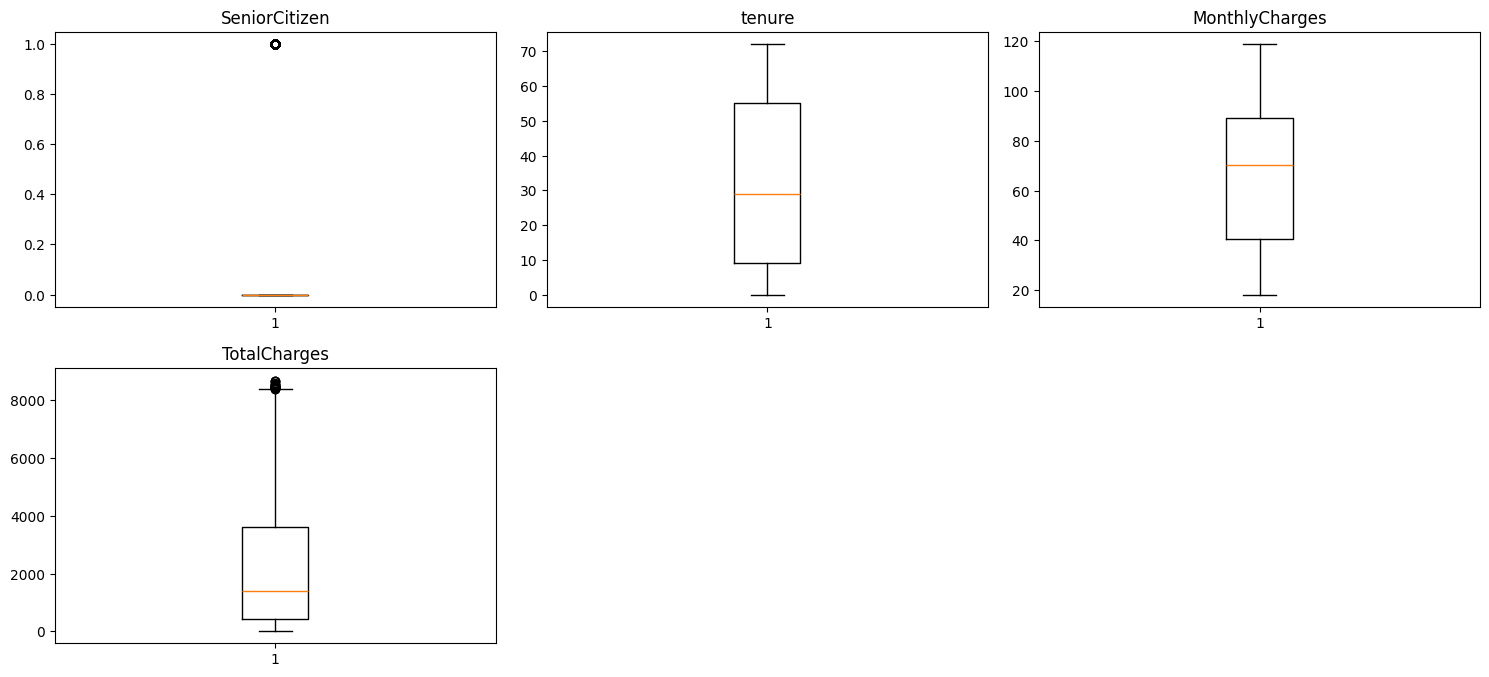

In [ ]:
# check outliers
plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(3,3,i)
    plt.boxplot(customer_df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [ ]:
# handle outliers
Q1 = customer_df[num_cols].quantile(0.25)
Q3 = customer_df[num_cols].quantile(0.75)

IQR = Q3 - Q1
lower_limit = Q1 - (1.5 * IQR)
upper_limit = Q3 + (1.5 * IQR)

In [ ]:
#clipping outliers
customer_df[num_cols] = customer_df[num_cols].clip(
    lower_limit,
    upper_limit,
    axis=1
)

In [ ]:
#remove duplicates
customer_df.duplicated().sum()


np.int64(0)

In [ ]:
customer_df.drop_duplicates(inplace=True)

##Feature Engineering

In [ ]:
#Customer Lifetime Value Feature
customer_df['Customer_Lifetime_Value'] = (
    customer_df['tenure'] * customer_df['MonthlyCharges'])

In [ ]:
#Tenure and Contract Interaction Feature
customer_df['Tenure_Contract'] = (
    customer_df['tenure'].astype(str)
    + '_'
    + customer_df['Contract'].astype(str)
)

In [ ]:
# Drop Unnecessary Columns
customer_df.drop('customerID', axis=1, inplace=True)

##Encoding

In [ ]:
label_encoder = LabelEncoder()
binary_cols = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
    'Churn'
]
for col in binary_cols:
    customer_df[col] = label_encoder.fit_transform(customer_df[col])

In [ ]:
customer_df = pd.get_dummies(customer_df, drop_first=True)

In [ ]:
##Feature scaling
scaler = StandardScaler()
scale_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'Customer_Lifetime_Value'
]

customer_df[scale_cols] = scaler.fit_transform(
    customer_df[scale_cols]
)

In [ ]:
#Split Combined Data Back into Train and Test
final_train = customer_df[
    customer_df['dataset_type_train'] == True
].copy()
final_test = customer_df[
    customer_df['dataset_type_train'] == False
].copy()

In [ ]:
#drop indicator columns
final_train.drop(
    ['dataset_type_train'],
    axis=1,
    inplace=True
)

final_test.drop(
    ['dataset_type_train'],
    axis=1,
    inplace=True
)

In [ ]:
#seperate features and target
X = final_train.drop('Churn', axis=1)

y = final_train['Churn']

In [ ]:
# split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

#Logistic regression

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print('Logistic Regression Accuracy:', accuracy_score(y_test, lr_pred))
print('Logistic Regression Precision:', precision_score(y_test, lr_pred))
print('Logistic Regression Recall:', recall_score(y_test, lr_pred))
print('Logistic Regression F1 Score:', f1_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))
print(confusion_matrix(y_test, lr_pred))

Logistic Regression Accuracy: 0.7772848269742679
Logistic Regression Precision: 0.6336996336996337
Logistic Regression Recall: 0.5339506172839507
Logistic Regression F1 Score: 0.5795644891122278
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       803
           1       0.63      0.53      0.58       324

    accuracy                           0.78      1127
   macro avg       0.73      0.70      0.71      1127
weighted avg       0.77      0.78      0.77      1127

[[703 100]
 [151 173]]


##KNN

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)

print('KNN Accuracy:', accuracy_score(y_test, knn_pred))
print('KNN Precision:', precision_score(y_test, knn_pred))
print('KNN Recall:', recall_score(y_test, knn_pred))
print('KNN F1 Score:', f1_score(y_test, knn_pred))
print(classification_report(y_test, knn_pred))
print(confusion_matrix(y_test, knn_pred))

KNN Accuracy: 0.7515527950310559
KNN Precision: 0.56875
KNN Recall: 0.5617283950617284
KNN F1 Score: 0.5652173913043478
              precision    recall  f1-score   support

           0       0.82      0.83      0.83       803
           1       0.57      0.56      0.57       324

    accuracy                           0.75      1127
   macro avg       0.70      0.69      0.70      1127
weighted avg       0.75      0.75      0.75      1127

[[665 138]
 [142 182]]


##Random Forest

In [ ]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print('Random Forest Accuracy:', accuracy_score(y_test, rf_pred))
print('Random Forest Precision:', precision_score(y_test, rf_pred))
print('Random Forest Recall:', recall_score(y_test, rf_pred))
print('Random Forest F1 Score:', f1_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))
print(confusion_matrix(y_test, rf_pred))

Random Forest Accuracy: 0.7781721384205856
Random Forest Precision: 0.6651785714285714
Random Forest Recall: 0.45987654320987653
Random Forest F1 Score: 0.5437956204379562
              precision    recall  f1-score   support

           0       0.81      0.91      0.85       803
           1       0.67      0.46      0.54       324

    accuracy                           0.78      1127
   macro avg       0.74      0.68      0.70      1127
weighted avg       0.77      0.78      0.76      1127

[[728  75]
 [175 149]]


##Decision tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

print('Decision Tree Accuracy:', accuracy_score(y_test, dt_pred))

print('Decision Tree Precision:', precision_score(y_test, dt_pred))

print('Decision Tree Recall:', recall_score(y_test, dt_pred))

print('Decision Tree F1 Score:', f1_score(y_test, dt_pred))
print(confusion_matrix(y_test, dt_pred))

Decision Tree Accuracy: 0.7027506654835848
Decision Tree Precision: 0.48220064724919093
Decision Tree Recall: 0.45987654320987653
Decision Tree F1 Score: 0.4707740916271722
[[643 160]
 [175 149]]


In [ ]:
#compare the models
result_df = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'Random Forest',
        'Decision Tree'
    ],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, dt_pred)
    ]
})

result_df

,Model,Accuracy
0,Logistic Regression,0.777285
1,KNN,0.751553
2,Random Forest,0.778172
3,Decision Tree,0.702751


##Hyperparameter Tuning using GridSearchCV

In [ ]:
#Logistic Regression Tuning
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear']
}
grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='accuracy'
)
grid_lr.fit(X_train, y_train)
print(grid_lr.best_params_)
best_lr = grid_lr.best_estimator_

# Generate predictions for the best model
best_pred = best_lr.predict(X_test)

print('Tuned Logistic Regression Accuracy:')
print(accuracy_score(y_test, best_pred))

{'C': 0.1, 'solver': 'liblinear'}
Tuned Logistic Regression Accuracy:
0.7834960070984915


In [ ]:
#KNN Hyperparameter Tuning
knn_param_grid = {
    'n_neighbors': [3,5,7,9],
    'weights': ['uniform', 'distance']
}
grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    knn_param_grid,
    cv=5,
    scoring='accuracy'
)
grid_knn.fit(X_train, y_train)
best_knn = grid_knn.best_estimator_
knn_tuned_pred = best_knn.predict(X_test)
print('Tuned KNN Accuracy:', accuracy_score(y_test, knn_tuned_pred))

Tuned KNN Accuracy: 0.7515527950310559


In [96]:
# Random Forest Hyperparameter Tuning

rf_param_grid = {
    'n_estimators': [50,100],
    'max_depth': [5,10,None],
    'min_samples_split': [2,5],
    'min_samples_leaf': [1,2]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=5,
    scoring='accuracy'
)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

rf_tuned_pred = best_rf.predict(X_test)

print('Tuned Random Forest Accuracy:',
      accuracy_score(y_test, rf_tuned_pred))



Tuned Random Forest Accuracy: 0.7763975155279503


In [ ]:
# Final best model
best_model = RandomForestClassifier(random_state=42)

best_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
#feature importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
9,Customer_Lifetime_Value,0.121331
8,TotalCharges,0.113763
7,MonthlyCharges,0.108012
4,tenure,0.089672
12,InternetService_Fiber optic,0.039083
29,PaymentMethod_Electronic check,0.030989
0,gender,0.023871
27,Contract_Two year,0.023259
6,PaperlessBilling,0.021749
15,OnlineSecurity_Yes,0.021189


##Business Insights
Important Insights

Customers with month-to-month contracts are more likely to churn.

Customers with higher monthly charges show higher churn.

Customers with longer tenure are less likely to churn.

Fiber optic internet users show higher churn rates.

Customers without tech support or online security are more likely to churn.